# Fundamental Deep Learning Architectures with PyTorch

### 1) Images & Convolutional Neural Networks
Images consist of picture elements called *pixels*, which contain color information. Grayscale images have one integer in (0-255) per *pixel*. Color images have three channels (Red, Green, Blue) per *pixel* and have one integer for each color channel. For this sample exercise, we will use cloud classification images.

In [3]:
# --------------------------------------------------------
# 0. Import Reaquired Libraries
# --------------------------------------------------------
import os, shutil, random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchmetrics import Precision, Recall

# --------------------------------------------------------
# 1. Dataset Preparation
# --------------------------------------------------------
# set the path to data
data_dir = "./data/Swimcat-extend"
print(f"Using dataset from: {data_dir}")
print(f"Path exists: {os.path.exists(data_dir)}")

# create Dataset using ImageFolder (metadata only, no transformations yet)
dataset = ImageFolder(
  root=data_dir
)
real_classes = dataset.classes
num_classes = len(real_classes)

print("\nDetected Cloud Categories:")
print(real_classes)

print(f"\nTotal Unique Classes: {num_classes}")
print(f"Total Images: {len(dataset)}")

# configure transformations
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)), # resize raw image first to 64x64 pixels
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    transforms.ToTensor() # convert to tensor lastly
])
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# split dataset into train and test sets
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

split_ratio = 0.8
random.seed(42)  # for reproducibility
# only create split folders if they do not already exist
if not os.path.exists(train_dir) or not os.path.exists(test_dir):

    for class_name in dataset.classes:
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)
        random.shuffle(images)

        split_index = int(len(images) * split_ratio)
        train_images = images[:split_index]
        test_images = images[split_index:]

        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        for image_name in train_images:
            src = os.path.join(class_path, image_name)
            dst = os.path.join(train_dir, class_name, image_name)
            shutil.copy(src, dst)

        for image_name in test_images:
            src = os.path.join(class_path, image_name)
            dst = os.path.join(test_dir, class_name, image_name)
            shutil.copy(src, dst)

    print("\nTrain/test folders created successfully.")

else:
    print("\nTrain/test folders already exist. Skipping split.")

# create Datasets with transformations
train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transforms
)
test_dataset = ImageFolder(
    root=test_dir,
    transform=test_transforms
)   
print(f"\nTrain Dataset: {len(train_dataset)} images")
print(f"Test Dataset: {len(test_dataset)} images")

# create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Using dataset from: ./data/Swimcat-extend
Path exists: True

Detected Cloud Categories:
['A-Clear Sky', 'B-Patterned Clouds', 'C-Thin White Clouds', 'D-Thick White Clouds', 'E-Thick Dark Clouds', 'F-Veil Clouds']

Total Unique Classes: 6
Total Images: 2100

Train/test folders created successfully.

Train Dataset: 1680 images
Test Dataset: 420 images


Data augmentation allows the model to learn from more examples of larger diversity, making it robust to real-world distortions. It tends to improve the model's performance, but it does not create more information than is already contained in the original images. If available, using more training data is preferred to creating it artificially with data augmentation.

In [4]:
images, labels = next(iter(train_dataloader))

print(images.shape)
print(labels.shape)
print(images.dtype)
print(labels.dtype)

torch.Size([32, 3, 64, 64])
torch.Size([32])
torch.float32
torch.int64


In [5]:
# --------------------------------------------------------
# 2. Convolutional Neural Network Architecture
# --------------------------------------------------------
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # Input size: (Batch_size, 3, 64, 64) for RGB images resized to 64x64
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Out: (32, 64, 64)
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2), # Out: (32, 32, 32)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Out: (64, 32, 32)
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2), # Out: (64, 16, 16)

            nn.Flatten(),  # Flatten to (64*16*16) for the classifier
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*16*16, 128),
            nn.ELU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x
    
# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    
# initialize the network with the number of classes
net = Net(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

Using device: cuda


While working with images, linear layers are slow to train (too many parameters!), prone to overfitting and do not recognize spatial patterns (can learn a pattern but cannot recognize if it appears in a different location). Thus, a better alternative is to use convolutional layers, in which the parameters are collected in one or more small grids called filters. Sliding filters over the input and performing convolution at each position results in feature map (one filter - one feature map), which use fewer parameters than linear layer and preserve spatial patterns.

In [6]:
# --------------------------------------------------------
# 3. Train the Model
# --------------------------------------------------------

for epoch in range(15):
    net.train()
    running_loss = 0.0

    # iterate over training batches
    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = net(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 1.1609
Epoch 2, Loss: 0.8033
Epoch 3, Loss: 0.6937
Epoch 4, Loss: 0.5775
Epoch 5, Loss: 0.6118
Epoch 6, Loss: 0.5623
Epoch 7, Loss: 0.4623
Epoch 8, Loss: 0.4369
Epoch 9, Loss: 0.4580
Epoch 10, Loss: 0.3783
Epoch 11, Loss: 0.3669
Epoch 12, Loss: 0.3625
Epoch 13, Loss: 0.3016
Epoch 14, Loss: 0.3361
Epoch 15, Loss: 0.2738


Minor bumps on loss value are not concerning and normal. Because training uses shuffled batches, augmentation adds randomness and Adam is stochastic.

<img src="https://www.kdnuggets.com/wp-content/uploads/selvaraj_confusion_matrix_precision_recall_explained_12.png" alt="Precision and Recall" width="40%"/>

###### Image credit: Kdnuggets

- **Precision:** Fraction of correct positive predictions
- **Recall:** Fraction of all positive examples correctly predicted

Multi-class metrics can be averaged by four approaches:
- *Not averaging:* Analyses the results per class.
- *Micro-averaging:* Ignores the classes and computes the metrics globally. Used on imbalanced datasets.
- *Macro-averaging:* Computes metrics per class and averages them. Used when performance is cared on small classes.
- *Weighted-averaging:* Computes metrics per class with the average weighted by class size. Used when the errors in large classes are considered as more important.

While aggregated metrics are useful indicators of the model's performance, it is often informative to look at the metrics per class. This could reveal classes for which the model underperforms.

In [7]:
# --------------------------------------------------------
# 4. Model Evaluation
# --------------------------------------------------------
from torchmetrics import Accuracy

metric_accuracy = Accuracy(
    task="multiclass",
    num_classes=num_classes
).to(device)

metric_precision = Precision(
    task="multiclass",
    num_classes=num_classes,
    average="macro"
).to(device)

metric_recall = Recall(
    task="multiclass",
    num_classes=num_classes,
    average="macro"
).to(device)

metric_precision_per_class = Precision(
    task="multiclass",
    num_classes=num_classes,
    average=None
).to(device)

net.eval()

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        preds = torch.argmax(outputs, dim=1)

        metric_accuracy.update(preds, labels)
        metric_precision.update(preds, labels)
        metric_recall.update(preds, labels)
        metric_precision_per_class.update(preds, labels)

accuracy = metric_accuracy.compute()
precision = metric_precision.compute()
recall = metric_recall.compute()
precision_per_class = metric_precision_per_class.compute().cpu()

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\nPrecision per class:")
for i, class_name in enumerate(real_classes):
    print(f"{class_name}: {precision_per_class[i]:.4f}")

Accuracy:  0.8762
Precision: 0.8784
Recall:    0.8762

Precision per class:
A-Clear Sky: 0.8046
B-Patterned Clouds: 0.9412
C-Thin White Clouds: 0.8125
D-Thick White Clouds: 0.7727
E-Thick Dark Clouds: 0.9857
F-Veil Clouds: 0.9538


The trained model can also be tested on unseen data here:

In [11]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

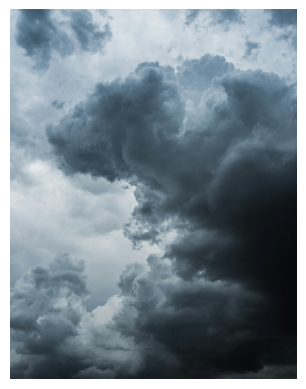

E-Thick Dark Clouds


In [19]:
url = "https://images.unsplash.com/photo-1534088568595-a066f410bcda" # any cloud image url here
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
x = test_transforms(image).unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.argmax(net(x), dim=1).item()

plt.imshow(image)
plt.axis("off")
plt.show()
print(real_classes[pred])

### 2) Sequences & Recurrent Neural Networks

Sequential data is ordered in time or space. Order of the data points contains dependencies between them. Some examples could be time series, text and audio waves. To be able to train neural networks on sequential data, data needs to be pre-processed first. It will be chunked into inputs-target pairs, where the inputs are some number of consecutive data points and the target is the next data point.

For time series:
- Data CANNOT be randomly splitted into train and test to avoid the risk of creating a look-ahead bias. Otherwise we would end up with a model, which already has information about the future, making forecasts.
- Split data by time: Train on earlier and test on later data.
- Sequence length is the number of data points in one training example.

In [81]:
# --------------------------------------------------------
# 0. Import Reaquired Libraries
# --------------------------------------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# --------------------------------------------------------
# 1. Dataset Preparation
# --------------------------------------------------------
# download a simple, clean time series dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# inspect what it looks like (Columns: 'Month', 'Passengers')
print(df.head())

values = df.iloc[:, 1].astype(float).values

# normalize (important for training stability)
mean = values.mean()
std = values.std()
values = (values - mean) / std

# create sequences as the sequential data
def create_sequences(values, seq_length):
    xs, ys = [], []
    for i in range(len(values) - seq_length):
        xs.append(values[i:i+seq_length])
        ys.append(values[i+seq_length])
    return np.array(xs), np.array(ys)

# use create_sequences to create inputs and targets
seq_length = 12
X, y = create_sequences(values, seq_length)

# time-based split (train on earlier data, test on later data to avoid look-ahead bias)
train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# reshape for RNN input
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Train shapes - X: (105, 12, 1), y: (105,)


In [85]:
# convert to tensors
dataset_train = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).float()
)
print(len(dataset_train))

# create a DataLoader for training
train_loader = DataLoader(dataset_train, batch_size=16, shuffle=False) # keep false for time series tracking if desired

105


Upon executing the data processing function, the output yields 105 training examples. Each example consists of 12 sequential inputs (representing the passenger counts of the preceding 12 months) and 1 target value (representing the passenger count of the subsequent month). The resulting TensorDataset functions identically to standard PyTorch dataset objects, allowing seamless integration with a DataLoader for batch management and iteration during model training.

RNNs are feed forward networks which have connections pointing back. They maintain memory through time, which allows them to handle sequential data well. Depending on the lengths of input and output sequences, there are four different architecture types:

- Sequence-to-sequence: pass sequence as input, use the entire output sequence (i.e. real-time speech recognition)
- Sequence-to-vector: pass sequence as input, use only the last output (i.e. text topic classification)
- Vector-to-sequence: pass single input, use the entire output sequence (i.e. text generation)
- Encoder-decoder: pass entire input sequence, only then start using the output sequence (i.e. machine translation)

Here a sequence-to-vector model consisting of an RNN layer with two layers and a hidden_size of 32 is built. After the RNN layer, a simple linear layer will map the outputs to a single value to be predicted.

In [86]:
# --------------------------------------------------------
# 2. Recurrent Neural Network Architecture
# --------------------------------------------------------
class RNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # h0 shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.rnn(x, h0)  
        # take the hidden state of the very last time step and pass through a linear layer
        out = self.fc(out[:, -1, :])
        return out

rnn_model = RNNNet()
print(rnn_model)

RNNNet(
  (rnn): RNN(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [87]:
# --------------------------------------------------------
# 3. Train the Model
# --------------------------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0001)

# training loop
rnn_model.train()
for epoch in range(100):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:

        # Ensure predictions and targets are both 1D vectors of identical shape
        preds = rnn_model(batch_X).view(-1)
        loss = criterion(preds, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        rmse = (epoch_loss / len(train_loader)) ** 0.5
        print(f"Epoch {epoch+1}: RMSE {rmse:.4f}")

Epoch 20: RMSE 0.5693
Epoch 40: RMSE 0.3559
Epoch 60: RMSE 0.3410
Epoch 80: RMSE 0.3250
Epoch 100: RMSE 0.3091


Here MSE (mean squared error) loss is used which ensures positive and negative errors do not cancel each other out and penalizes large errors more. Also to ensure that the shape of predictions perfectly match the shape of targets, tensors should be extended using `view()` function or squeezed using `squeeze()` function. 

In [88]:
# --------------------------------------------------------
# 4. Model Evaluation
# --------------------------------------------------------
from torchmetrics import MeanSquaredError

# define MSE metric
mse = MeanSquaredError()

rnn_model.eval()

# convert test data to tensors
X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).float()

with torch.no_grad():
    # flatten into a 1d vector
    preds = rnn_model(X_test_t).view(-1)
    mse(preds, y_test_t)

# convert back to original scale
preds_real = preds * std + mean
actual_real = y_test_t * std + mean

# print a few examples
for i in range(5):
    print(f"Predicted: {preds_real[i].item():.1f} | Actual: {actual_real[i].item():.1f}")

# compute final metric value
test_mse = mse.compute()
print(f"Test MSE: {test_mse}")

Predicted: 414.3 | Actual: 359.0
Predicted: 397.8 | Actual: 310.0
Predicted: 382.6 | Actual: 337.0
Predicted: 377.5 | Actual: 360.0
Predicted: 382.9 | Actual: 342.0
Test MSE: 0.3621580898761749


Although the dateset is very limited, the simple RNN model predicts relatively okay. But RNN cells maintain the memory via hidden state and this memory is very short-term. Hence, two more powerful cells solve this problem:
- LSTM (Long Short-Term Memory) cell
- GRU (Gated Recurrent Unit) cell

**Long Short-Term Memory**:

LSTM cells have three inputs and outputs with two hidden states as short-term state (`h`) and long-term state (`c`). They include three gates which are **forget gate** to decide what to remove from long-term memory, **input gate** to decide what to save to long-term memory and **output gate** to decide what to return at the current time step.

In [ ]:
# --------------------------------------------------------
# 2.a Long Short-Term Memory Architecture
# --------------------------------------------------------
class LSTMNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # h0 shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(2, x.size(0), 32)
        # c0 shape: (num_layers, batch_size, hidden_size)
        c0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out
    
lstm_model = LSTMNet()
print(lstm_model)

**Gated Recurrent Unit**:

GRU cells are simplified version of LSTM cells. They have only one hidden state (`h`) as they merge the long-term and short-term memories into a single hidden state. Thy also don't use an **output gate** and the entire hidden state is returned at each time step.

In [ ]:
# --------------------------------------------------------
# 2.b Gated Recurrent Unit Architecture
# --------------------------------------------------------
class GRUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # h0 shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.gru(x, h0)  
        # take the hidden state of the very last time step and pass through a linear layer
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRUNet()
print(gru_model)

**RNN vs LSTM vs GRU?**

Although plain RNNs have revolutionized modeling of sequential data, they are not used these days due to short-term memory problem. While deciding between LSTM and GRU, GRU is simpler than LSTM and requires less computation. However the relative performance varies by the usa case and it is generally a good idea to try both to see which one performs better. 

### 3) Multi-Input & Multi-Output Architectures

**Multi-input** architectures are required while building models using more information about a particular sample, defining multi-modal models using multiple modalities like text and image, during metric learning in order to match multiple inputs, and also during self-supervised learning to match multiple augmentations of the same sample. 

Below is a multi-input model implementation for handwritten character classifier:

In [ ]:
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [ ]:
class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
		# Assign transform and samples to class attributes
        self.transform = transform
        self.samples = samples
                    
    def __len__(self):
		# Return number of samples
        return len(self.samples)

    def __getitem__(self, idx):
      	# Unpack the sample at index idx
        img_path, alphabet, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        # Transform the image 
        img_transformed = self.transform(img)
        return img_transformed, alphabet, label

In [ ]:
dataset_train = OmniglotDataset(
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((64, 64)),
    ]),
    samples=samples,
)

dataloader_train = DataLoader(
    dataset_train, shuffle=True, batch_size=3,
)

In [ ]:
next(iter(dataloader_train))

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define sub-networks as sequential models
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        self.alphabet_layer = nn.Sequential(
            nn.Linear(30, 8),
            nn.ELU(), 
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 8, 964), 
        )
        
    def forward(self, x_image, x_alphabet):
		# Pass the x_image and x_alphabet through appropriate layers
        x_image = self.image_layer(x_image)
        x_alphabet = self.alphabet_layer(x_alphabet)
        # Concatenate x_image and x_alphabet
        x = torch.cat((x_image, x_alphabet), dim=1)
        return self.classifier(x)

In [ ]:
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

for epoch in range(10):
    for img, alpha, labels in dataloader_train:        
        optimizer.zero_grad()        
        outputs = net(img, alpha)        
        loss = criterion(outputs, labels)        
        loss.backward()        
        optimizer.step()

**Multi-output** architectures are used for multi-task learning where the model learns two separate things, and for multi-label classification where the input class can be defined in multiple classes. Another usage is for regularization in very deep models by adding extra outputs predicting the same targets after each block. These additional outputs ensure that the early parts of the model are learning features useful for the task at hand as well as a performing a form of regularization.

Below is a multi-output model implementation for handwritten character classifier predicting the character and its alphabet:

In [ ]:
class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):        
        self.transform = transform        
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):        
        img_path, alphabet, label = self.samples[idx]        
        img = Image.open(img_path).convert('L')        
        img = self.transform(img)
        return img, alphabet, label

In [ ]:
# Print the sample at index 100
print(samples[100])

# Create dataset_train
dataset_train = OmniglotDataset(
    transform=transforms.Compose([
        transforms.ToTensor(),
      	transforms.Resize((64, 64)),
    ]),
    samples=samples,
)

# Create dataloader_train
dataloader_train = DataLoader(
    dataset_train, shuffle=True, batch_size=3,
)

In [ ]:
class Net(nn.Module):
    def __init__(self, num_alpha, num_char):
        super().__init__()        
        self.image_layer = nn.Sequential(            
            nn.Conv2d(1, 16, kernel_size=3, padding=1),            
            nn.MaxPool2d(kernel_size=2),            
            nn.ELU(),            
            nn.Flatten(),            
            nn.Linear(16*32*32, 128)        
        )        
        self.classifier_alpha = nn.Linear(128, 30)        
        self.classifier_char = nn.Linear(128, 964)
        
    def forward(self, x):        
        x_image = self.image_layer(x)        
        output_alpha = self.classifier_alpha(x_image)        
        output_char = self.classifier_char(x_image)
        return output_alpha, output_char

In [ ]:
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.05)

for epoch in range(1):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        outputs_alpha, outputs_char = net(images)
        # Compute alphabet classification loss
        loss_alpha = criterion(outputs_alpha, labels_alpha)
        # Compute character classification loss
        loss_char = criterion(outputs_char, labels_char)
        # Compute total loss (sum fo equal importance of both losses)
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()

For varying task importance on multi-output models, use multiplicants to more important loss or assign weights that sum up to 1. Losses must be on the same scale before they are weighted and added.

```python
loss_price = loss_price / torch.max(loss_price)loss_quality = loss_quality / torch.max(loss_quality)loss = 0.7 * loss_price + 0.3 * loss_quality
```

In [ ]:
def evaluate_model(model):
    # Define accuracy metrics
    acc_alpha = Accuracy(task="multiclass", num_classes=30)
    acc_char = Accuracy(task="multiclass", num_classes=964)

    model.eval()
    with torch.no_grad():
        for images, labels_alpha, labels_char in dataloader_test:
            # Obtain model outputs
            outputs_alpha, outputs_char = model(images)
            _, pred_alpha = torch.max(outputs_alpha, 1)
            _, pred_char = torch.max(outputs_char, 1)
			# Update both accuracy metrics
            acc_alpha(pred_alpha, labels_alpha)
            acc_char(pred_char, labels_char)
    
    print(f"Alphabet: {acc_alpha.compute()}")
    print(f"Character: {acc_char.compute()}")